# Explainable AI for Stress Factors
## Deciphering Sleep and Lifestyle Impacts on Stress Score

**Target:** `stress_score` (kontinu, 1.0–10.0) → **Regression Task**

Pipeline 6 phase + struktur modular:
1. **Setup & EDA** — load, distribusi, korelasi
2. **Preprocessing** — drop co-outcomes, split 70/15/15
3. **Model Training** — *modular* (`train_catboost`, `train_random_forest`, `test_catboost`, `test_random_forest`)
4. **Global SHAP** — 4a (CatBoost) + 4b (Random Forest) + 4c (Cross-Model)
5. **Individual SHAP** — 3 kasus + Waterfall + Force Plot
6. **Final Report** — verification + insights

**Estimasi runtime:** ~12–18 menit (RF SHAP +5-10 min vs sebelumnya).

## Setup — Imports

In [1]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import kendalltau

from catboost import CatBoostRegressor, Pool
import shap

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

NUMERIC_FEATURES = [
    "age", "bmi", "sleep_duration_hrs", "sleep_quality_score",
    "rem_percentage", "deep_sleep_percentage", "sleep_latency_mins",
    "wake_episodes_per_night", "caffeine_mg_before_bed",
    "alcohol_units_before_bed", "screen_time_before_bed_mins",
    "steps_that_day", "nap_duration_mins", "work_hours_that_day",
    "heart_rate_resting_bpm", "room_temperature_celsius",
    "weekend_sleep_diff_hrs", "exercise_day", "sleep_aid_used", "shift_work",
]
CATEGORICAL_FEATURES = [
    "gender", "occupation", "country", "chronotype",
    "mental_health_condition", "season", "day_type",
]
DROP_COLS = ["person_id", "cognitive_performance_score", "sleep_disorder_risk", "felt_rested"]
TARGET = "stress_score"
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f"Total fitur input: {len(ALL_FEATURES)} ({len(NUMERIC_FEATURES)} num + {len(CATEGORICAL_FEATURES)} kat)")

Total fitur input: 27 (20 num + 7 kat)


---

## Phase 1 — Setup & EDA

In [2]:
df = pd.read_csv("sleep_health_dataset.csv")
print(f"Shape: {df.shape}  Missing: {df.isna().sum().sum()}")
print(df[TARGET].describe().round(3))

Shape: (100000, 32)  Missing: 0
count    100000.000
mean          5.733
std           1.619
min           1.000
25%           4.800
50%           5.800
75%           6.800
max          10.000
Name: stress_score, dtype: float64


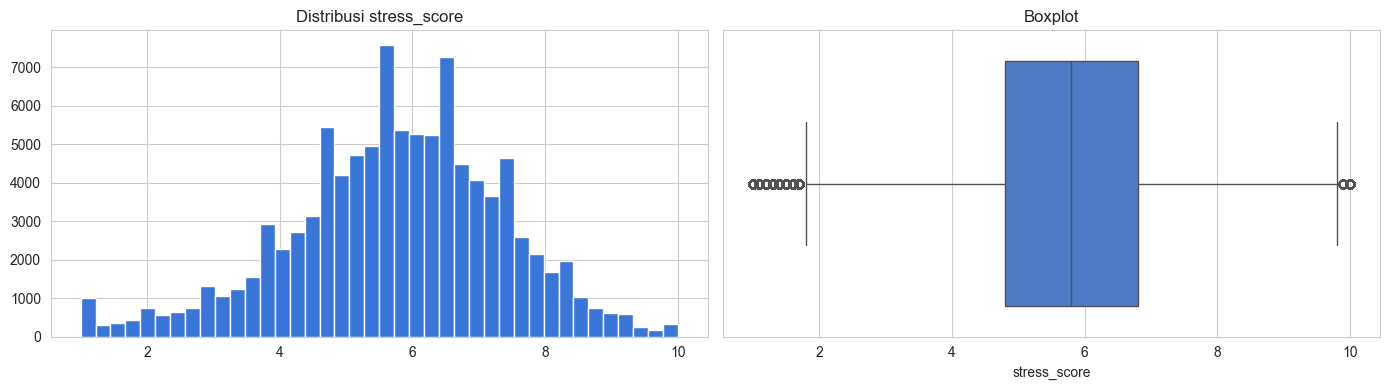

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df[TARGET], bins=40, color="#3a76d8", edgecolor="white")
axes[0].set_title("Distribusi stress_score")
sns.boxplot(x=df[TARGET], ax=axes[1], color="#3a76d8")
axes[1].set_title("Boxplot")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/eda_target_distribution.png", dpi=120)
plt.show()

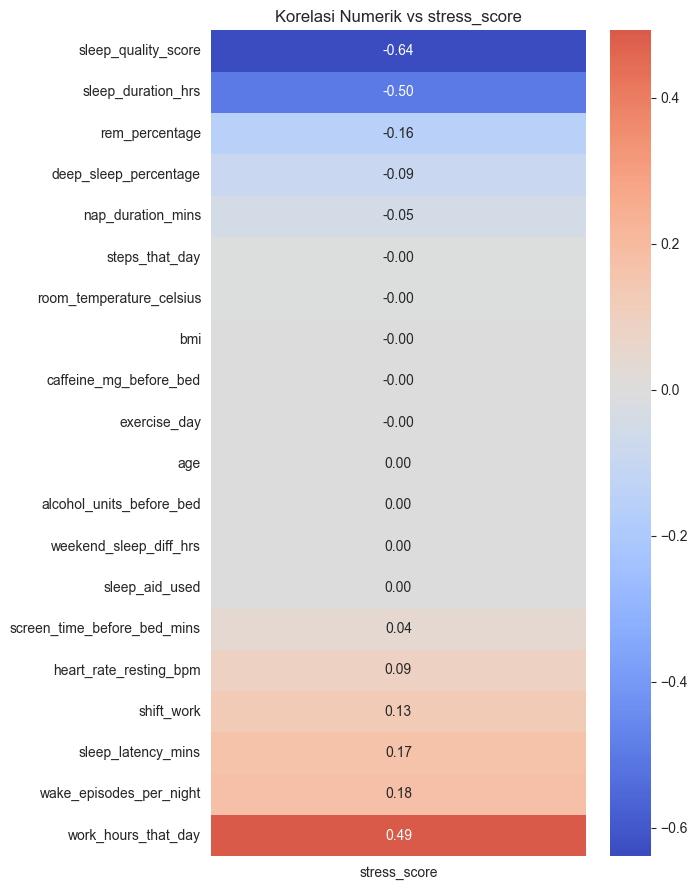

Top-5 korelasi |r|:
 sleep_quality_score       -0.639
sleep_duration_hrs        -0.500
work_hours_that_day        0.493
wake_episodes_per_night    0.175
sleep_latency_mins         0.169


In [4]:
num_corr = df[NUMERIC_FEATURES + [TARGET]].corr()[[TARGET]].drop(TARGET).sort_values(by=TARGET)
plt.figure(figsize=(7, 9))
sns.heatmap(num_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korelasi Numerik vs stress_score")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/eda_correlation_heatmap.png", dpi=120)
plt.show()

corr_abs = df[NUMERIC_FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("Top-5 korelasi |r|:\n", corr_abs.head(5).round(3).to_string())

---

## Phase 2 — Preprocessing & Split

In [5]:
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

bins = pd.qcut(y, q=5, labels=False, duplicates="drop")
X_temp, X_test, y_temp, y_test, bins_temp, _ = train_test_split(
    X, y, bins, test_size=0.15, random_state=RANDOM_SEED, stratify=bins
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=RANDOM_SEED, stratify=bins_temp
)
for c in CATEGORICAL_FEATURES:
    X_train[c] = X_train[c].astype(str)
    X_val[c] = X_val[c].astype(str)
    X_test[c] = X_test[c].astype(str)

for col in ["sleep_disorder_risk", "cognitive_performance_score", "felt_rested"]:
    assert col not in X_train.columns
print("[OK] Leakage guard verified.")
print(pd.DataFrame({
    "n": [len(y_train), len(y_val), len(y_test)],
    "%": [len(y_train)/len(y)*100, len(y_val)/len(y)*100, len(y_test)/len(y)*100],
    "mean": [y_train.mean(), y_val.mean(), y_test.mean()],
}, index=["Train", "Val", "Test"]).round(3))

[OK] Leakage guard verified.
           n       %   mean
Train  69997  69.997  5.734
Val    15003  15.003  5.724
Test   15000  15.000  5.741


---

## Phase 3 — Model Training (Modular)

Struktur baru: train & test **dipisah per model** untuk modularitas:

| Fungsi | Tugas |
|---|---|
| `encode_for_rf` | Encode kategorikal untuk Random Forest |
| `train_catboost` | Train CatBoost dengan early stopping |
| `train_random_forest` | Train Random Forest |
| `evaluate_model` | Hitung R²/RMSE/MAE |
| `test_catboost` | Test CatBoost (Val + Test) |
| `test_random_forest` | Test Random Forest (Val + Test) |

### 3.1 Definisi Fungsi Modular

In [6]:
def encode_for_rf(X_train, X_val, X_test):
    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_train_rf = X_train.copy(); X_val_rf = X_val.copy(); X_test_rf = X_test.copy()
    X_train_rf[CATEGORICAL_FEATURES] = encoder.fit_transform(X_train_rf[CATEGORICAL_FEATURES])
    X_val_rf[CATEGORICAL_FEATURES] = encoder.transform(X_val_rf[CATEGORICAL_FEATURES])
    X_test_rf[CATEGORICAL_FEATURES] = encoder.transform(X_test_rf[CATEGORICAL_FEATURES])
    return encoder, X_train_rf, X_val_rf, X_test_rf

def train_catboost(X_train, y_train, X_val, y_val):
    cat_idx = [X_train.columns.get_loc(c) for c in CATEGORICAL_FEATURES]
    train_pool = Pool(X_train, y_train, cat_features=cat_idx)
    val_pool = Pool(X_val, y_val, cat_features=cat_idx)
    model = CatBoostRegressor(
        iterations=1000, learning_rate=0.05, depth=6,
        eval_metric="RMSE", early_stopping_rounds=50,
        random_seed=RANDOM_SEED, verbose=200,
    )
    model.fit(train_pool, eval_set=val_pool, use_best_model=True)
    return model

def train_random_forest(X_train_rf, y_train):
    model = RandomForestRegressor(
        n_estimators=300, min_samples_leaf=5,
        n_jobs=-1, random_state=RANDOM_SEED,
    )
    model.fit(X_train_rf, y_train)
    return model

def evaluate_model(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": mean_absolute_error(y_true, y_pred),
    }

def test_catboost(model, X_test, y_test, X_val=None, y_val=None):
    out = {}
    if X_val is not None: out["val"] = evaluate_model(y_val, model.predict(X_val))
    out["test"] = evaluate_model(y_test, model.predict(X_test))
    return out

def test_random_forest(model, X_test_rf, y_test, X_val_rf=None, y_val=None):
    out = {}
    if X_val_rf is not None: out["val"] = evaluate_model(y_val, model.predict(X_val_rf))
    out["test"] = evaluate_model(y_test, model.predict(X_test_rf))
    return out

print("[OK] 6 modular functions defined")

[OK] 6 modular functions defined


### 3.2 Train CatBoost

In [7]:
print("[Training CatBoost...]")
t0 = time.time()
cat_model = train_catboost(X_train, y_train, X_val, y_val)
print(f"CatBoost trained in {time.time()-t0:.1f}s")

[Training CatBoost...]


0:	learn: 1.5747075	test: 1.5675720	best: 1.5675720 (0)	total: 240ms	remaining: 3m 59s


200:	learn: 0.9618674	test: 0.9614372	best: 0.9614372 (200)	total: 34.2s	remaining: 2m 16s


400:	learn: 0.9428499	test: 0.9522338	best: 0.9522338 (400)	total: 1m 14s	remaining: 1m 51s


600:	learn: 0.9317572	test: 0.9503331	best: 0.9503331 (600)	total: 1m 55s	remaining: 1m 16s


800:	learn: 0.9231419	test: 0.9497680	best: 0.9497103 (774)	total: 2m 25s	remaining: 36s


Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9497102676
bestIteration = 774

Shrink model to first 775 iterations.
CatBoost trained in 148.3s


### 3.3 Encode + Train Random Forest

In [8]:
encoder, X_train_rf, X_val_rf, X_test_rf = encode_for_rf(X_train, X_val, X_test)
print("[Encoded for RF]")

print("[Training Random Forest...]")
t0 = time.time()
rf_model = train_random_forest(X_train_rf, y_train)
print(f"RF trained in {time.time()-t0:.1f}s")

[Encoded for RF]
[Training Random Forest...]


RF trained in 34.4s


### 3.4 Test Kedua Model

In [9]:
cat_metrics = test_catboost(cat_model, X_test, y_test, X_val, y_val)
rf_metrics = test_random_forest(rf_model, X_test_rf, y_test, X_val_rf, y_val)
results = {"CatBoost": cat_metrics, "RandomForest": rf_metrics}

# Tabel perbandingan
rows = []
for model_name in ["CatBoost", "RandomForest"]:
    for split in ["val", "test"]:
        rows.append({"Model": model_name, "Split": split,
                     **{k: round(v, 4) for k, v in results[model_name][split].items()}})
print(pd.DataFrame(rows).to_string(index=False))

       Model Split     R2   RMSE    MAE
    CatBoost   val 0.6536 0.9497 0.7565
    CatBoost  test 0.6456 0.9639 0.7699
RandomForest   val 0.6278 0.9844 0.7833
RandomForest  test 0.6191 0.9993 0.7980


### 3.5 5-Fold CV Stability

In [10]:
rng = np.random.RandomState(RANDOM_SEED)
sub_idx = rng.choice(len(X_train), size=30000, replace=False)
X_sub = X_train.iloc[sub_idx].reset_index(drop=True)
y_sub = y_train.iloc[sub_idx].reset_index(drop=True)
X_sub_rf = X_train_rf.iloc[sub_idx].reset_index(drop=True)
cat_idx = [X_sub.columns.get_loc(c) for c in CATEGORICAL_FEATURES]

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cat_cv, rf_cv = [], []
for fold, (tr, te) in enumerate(kf.split(X_sub), 1):
    cm = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6,
                           random_seed=RANDOM_SEED, verbose=0)
    cm.fit(Pool(X_sub.iloc[tr], y_sub.iloc[tr], cat_features=cat_idx))
    cat_cv.append(r2_score(y_sub.iloc[te], cm.predict(X_sub.iloc[te])))
    rm = RandomForestRegressor(n_estimators=150, min_samples_leaf=5,
                               n_jobs=-1, random_state=RANDOM_SEED)
    rm.fit(X_sub_rf.iloc[tr], y_sub.iloc[tr])
    rf_cv.append(r2_score(y_sub.iloc[te], rm.predict(X_sub_rf.iloc[te])))
    print(f"  Fold {fold}: CB={cat_cv[-1]:.4f}  RF={rf_cv[-1]:.4f}")

results["CatBoost"]["cv_r2_mean"] = float(np.mean(cat_cv))
results["CatBoost"]["cv_r2_std"] = float(np.std(cat_cv))
results["RandomForest"]["cv_r2_mean"] = float(np.mean(rf_cv))
results["RandomForest"]["cv_r2_std"] = float(np.std(rf_cv))

best_name = "CatBoost" if results["CatBoost"]["val"]["R2"] >= results["RandomForest"]["val"]["R2"] else "RandomForest"
print(f"\n[BEST MODEL] {best_name}")

  Fold 1: CB=0.6480  RF=0.6236


  Fold 2: CB=0.6323  RF=0.6093


  Fold 3: CB=0.6439  RF=0.6195


  Fold 4: CB=0.6360  RF=0.6109


  Fold 5: CB=0.6471  RF=0.6221

[BEST MODEL] CatBoost


### 3.6 Visual Comparison

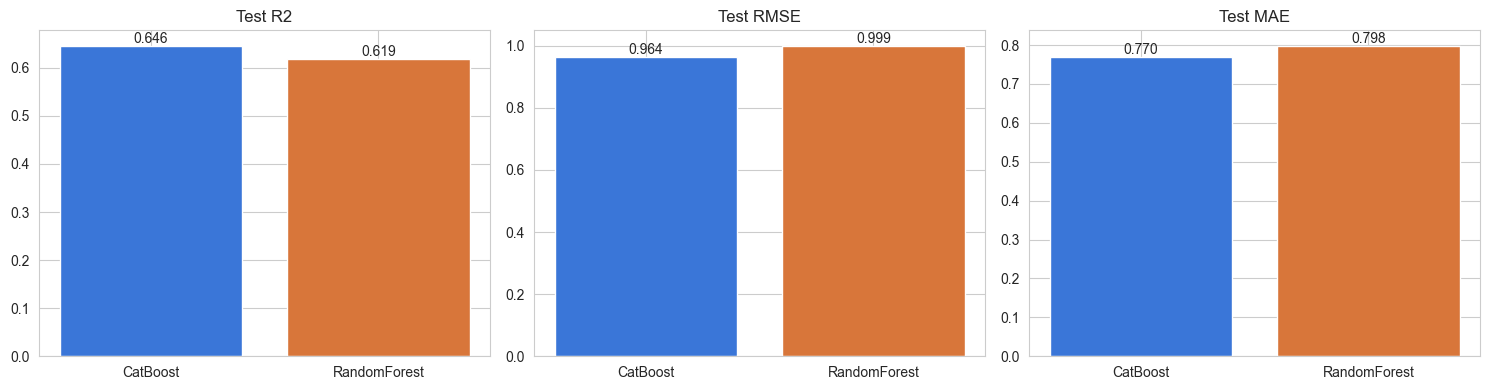

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, m in enumerate(["R2", "RMSE", "MAE"]):
    vals = [results["CatBoost"]["test"][m], results["RandomForest"]["test"][m]]
    bars = ax[i].bar(["CatBoost", "RandomForest"], vals, color=["#3a76d8", "#d8763a"])
    ax[i].set_title(f"Test {m}")
    for b, v in zip(bars, vals):
        ax[i].text(b.get_x()+b.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/model_comparison.png", dpi=120)
plt.show()

with open(f"{OUT_DIR}/model_metrics.json", "w") as f:
    json.dump(results, f, indent=2)

---

## Phase 4a — Global SHAP (CatBoost)

In [12]:
n_sample = 5000
rng = np.random.RandomState(RANDOM_SEED)
sample_idx = rng.choice(len(X_test), size=n_sample, replace=False)
X_shap = X_test.iloc[sample_idx].reset_index(drop=True)
y_shap = y_test.iloc[sample_idx].reset_index(drop=True)

print(f"Computing CatBoost SHAP on {n_sample} samples...")
explainer = shap.TreeExplainer(cat_model)
shap_pool = Pool(X_shap, cat_features=cat_idx)
shap_values = explainer.shap_values(shap_pool)
expected_value = float(explainer.expected_value)
print(f"SHAP shape: {shap_values.shape}  base: {expected_value:.4f}")

# Sanity
preds = cat_model.predict(X_shap)
diff = np.abs(shap_values.sum(axis=1) + expected_value - preds).max()
print(f"[Sanity] max diff = {diff:.10f}")
assert diff < 0.01

Computing CatBoost SHAP on 5000 samples...


SHAP shape: (5000, 27)  base: 5.7337
[Sanity] max diff = 0.0000000000


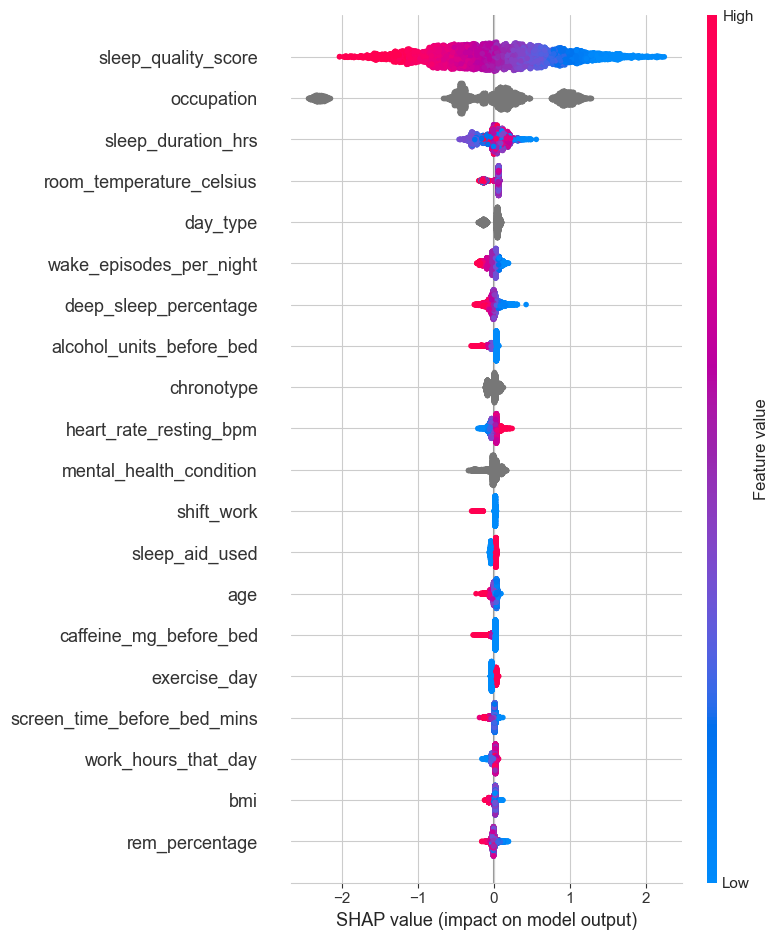

In [13]:
plt.figure()
shap.summary_plot(shap_values, X_shap, show=False, max_display=20)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/shap_summary_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

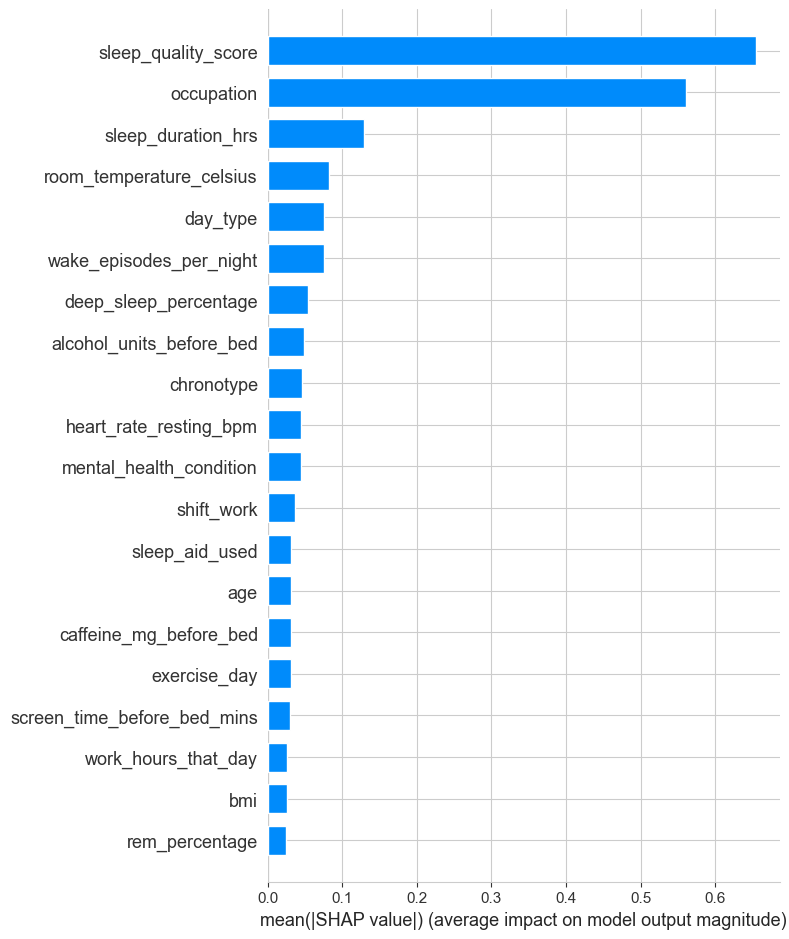

Top-10 CatBoost SHAP:
sleep_quality_score         0.6542
occupation                  0.5606
sleep_duration_hrs          0.1295
room_temperature_celsius    0.0828
day_type                    0.0758
wake_episodes_per_night     0.0755
deep_sleep_percentage       0.0548
alcohol_units_before_bed    0.0483
chronotype                  0.0464
heart_rate_resting_bpm      0.0445


In [14]:
plt.figure()
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False, max_display=20)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/shap_bar_importance.png", dpi=120, bbox_inches="tight")
plt.show()

feat_imp = pd.Series(np.abs(shap_values).mean(axis=0), index=X_shap.columns).sort_values(ascending=False)
print("Top-10 CatBoost SHAP:")
print(feat_imp.head(10).round(4).to_string())

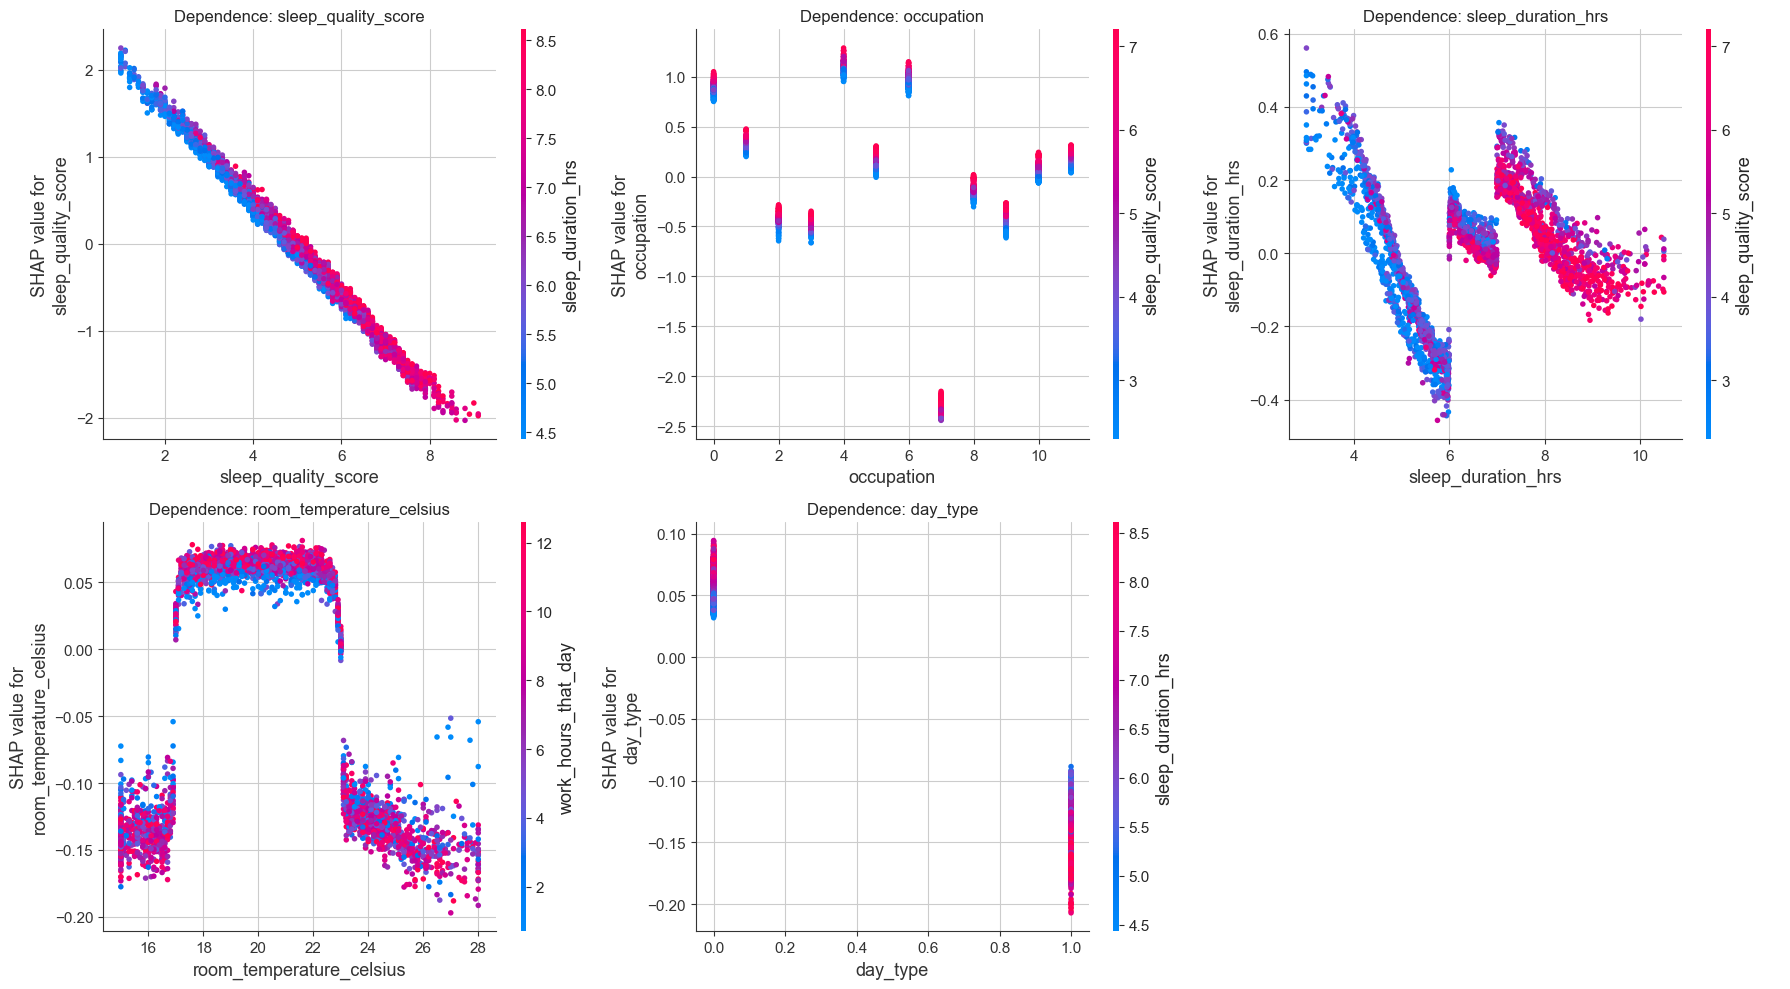

In [15]:
top5 = feat_imp.head(5).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, feat in enumerate(top5):
    if feat in CATEGORICAL_FEATURES:
        X_dep = X_shap.copy()
        X_dep[feat] = pd.Categorical(X_dep[feat]).codes
        shap.dependence_plot(feat, shap_values, X_dep, ax=axes[i], show=False)
    else:
        shap.dependence_plot(feat, shap_values, X_shap, ax=axes[i], show=False)
    axes[i].set_title(f"Dependence: {feat}")
axes[-1].axis("off")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/shap_dependence_top5.png", dpi=120)
plt.show()

### 4a.5 Within-Model Stability (5-Fold CV CatBoost)

  Fold 1 top-3: ['sleep_quality_score', 'occupation', 'sleep_duration_hrs']


  Fold 2 top-3: ['sleep_quality_score', 'occupation', 'sleep_duration_hrs']


  Fold 3 top-3: ['sleep_quality_score', 'occupation', 'sleep_duration_hrs']


  Fold 4 top-3: ['sleep_quality_score', 'occupation', 'sleep_duration_hrs']


  Fold 5 top-3: ['sleep_quality_score', 'occupation', 'sleep_duration_hrs']

Mean Kendall's Tau (within CatBoost, 5-fold): 0.8963


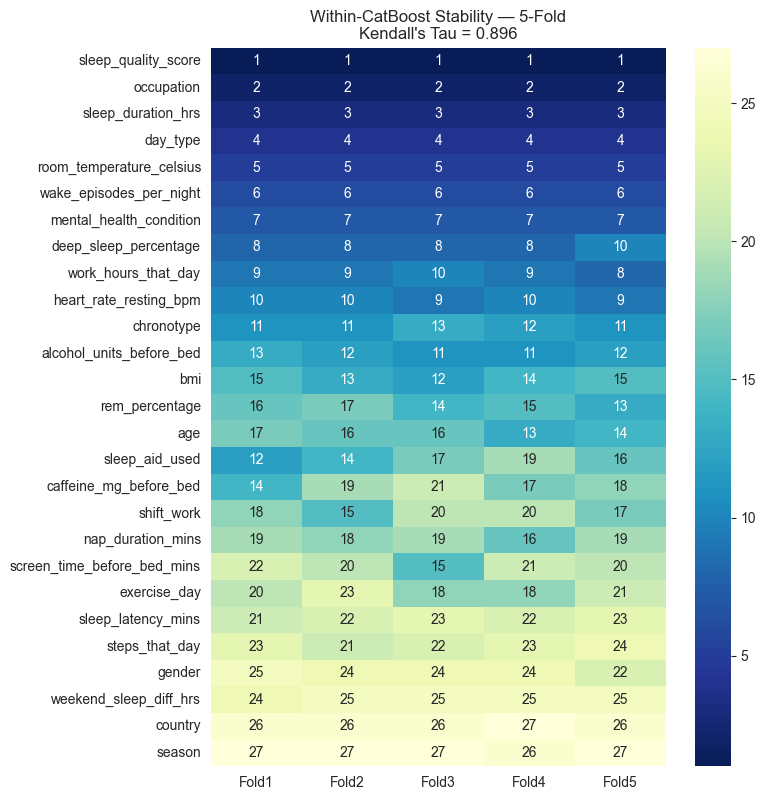

In [16]:
rng = np.random.RandomState(RANDOM_SEED)
sub_idx = rng.choice(len(X_train), size=20000, replace=False)
X_sub = X_train.iloc[sub_idx].reset_index(drop=True)
y_sub = y_train.iloc[sub_idx].reset_index(drop=True)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
fold_rankings = []
for fold, (tr, te) in enumerate(kf.split(X_sub), 1):
    cm = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6,
                           random_seed=RANDOM_SEED, verbose=0)
    cm.fit(Pool(X_sub.iloc[tr], y_sub.iloc[tr], cat_features=cat_idx))
    sv = shap.TreeExplainer(cm).shap_values(Pool(X_sub.iloc[te], cat_features=cat_idx))
    imp = np.abs(sv).mean(axis=0)
    ranking = pd.Series(imp, index=X_sub.columns).rank(ascending=False).astype(int)
    fold_rankings.append(ranking)
    print(f"  Fold {fold} top-3: {ranking.sort_values().head(3).index.tolist()}")

taus = []
for i in range(5):
    for j in range(i+1, 5):
        tau, _ = kendalltau(fold_rankings[i], fold_rankings[j])
        taus.append(tau)
mean_tau = float(np.mean(taus))
print(f"\nMean Kendall's Tau (within CatBoost, 5-fold): {mean_tau:.4f}")

rank_df = pd.concat(fold_rankings, axis=1)
rank_df.columns = [f"Fold{i+1}" for i in range(5)]
rank_df["mean_rank"] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values("mean_rank")
plt.figure(figsize=(8, max(8, len(rank_df)*0.3)))
sns.heatmap(rank_df[[f"Fold{i+1}" for i in range(5)]], annot=True, fmt=".0f", cmap="YlGnBu_r")
plt.title(f"Within-CatBoost Stability — 5-Fold\nKendall's Tau = {mean_tau:.3f}")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/shap_stability_heatmap.png", dpi=120)
plt.show()

---

## Phase 4b — Global SHAP (Random Forest)

**BARU.** SHAP analysis untuk Random Forest. Menggunakan TreeExplainer juga (sama seperti CatBoost) tapi pada data yang sudah di-encode.

> ⚠️ **RF SHAP jauh lebih lambat** dari CatBoost — sample 500 saja (~9 menit pada 300 trees). Untuk produksi/eksperimen lebih lanjut, bisa naikkan sample-nya.

In [17]:
n_sample_rf = 500
rng = np.random.RandomState(RANDOM_SEED)
sample_idx_rf = rng.choice(len(X_test_rf), size=n_sample_rf, replace=False)
X_shap_rf = X_test_rf.iloc[sample_idx_rf].reset_index(drop=True)

print(f"Computing RF SHAP on {n_sample_rf} samples (~9 menit untuk 300 trees)...")
t0 = time.time()
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_shap_rf)

# Robust expected_value: bisa scalar atau ndarray tergantung versi shap
ev = explainer_rf.expected_value
expected_value_rf = float(np.asarray(ev).ravel()[0])

print(f"  Done in {time.time()-t0:.1f}s")
print(f"  SHAP shape: {shap_values_rf.shape}  base: {expected_value_rf:.4f}")

# Sanity check RF
preds_rf = rf_model.predict(X_shap_rf)
diff_rf = np.abs(shap_values_rf.sum(axis=1) + expected_value_rf - preds_rf).max()
print(f"[Sanity RF] max diff = {diff_rf:.10f}")
assert diff_rf < 0.01

Computing RF SHAP on 500 samples (~9 menit untuk 300 trees)...


  Done in 1057.6s
  SHAP shape: (500, 27)  base: 5.7338
[Sanity RF] max diff = 0.0000000000


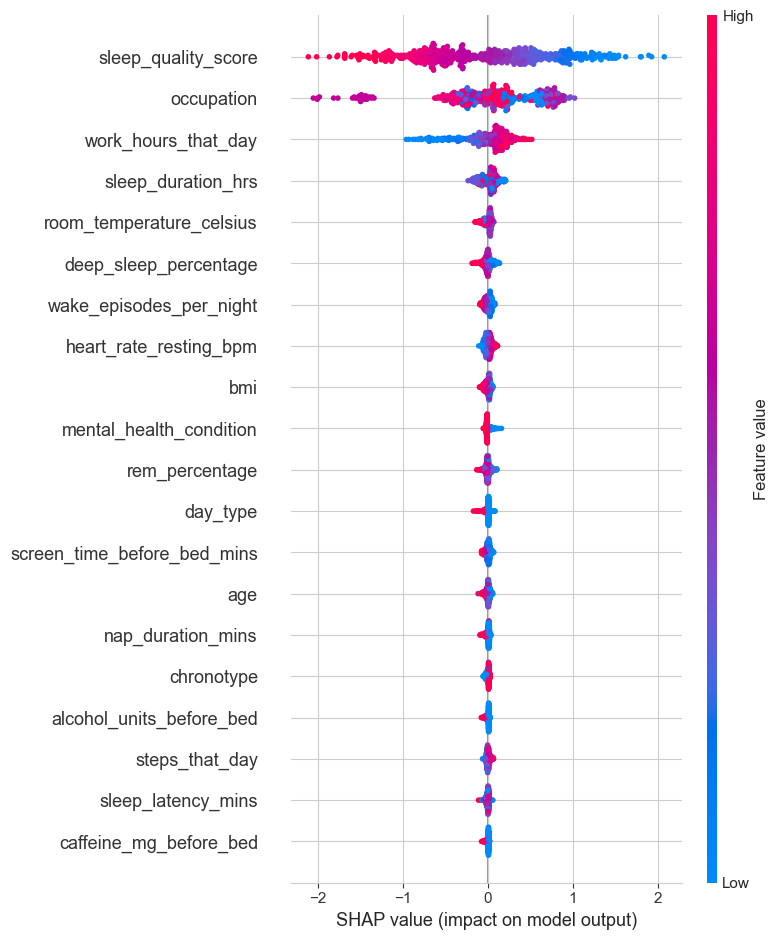

In [18]:
# Summary plot RF
plt.figure()
shap.summary_plot(shap_values_rf, X_shap_rf, show=False, max_display=20)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/shap_summary_beeswarm_rf.png", dpi=120, bbox_inches="tight")
plt.show()

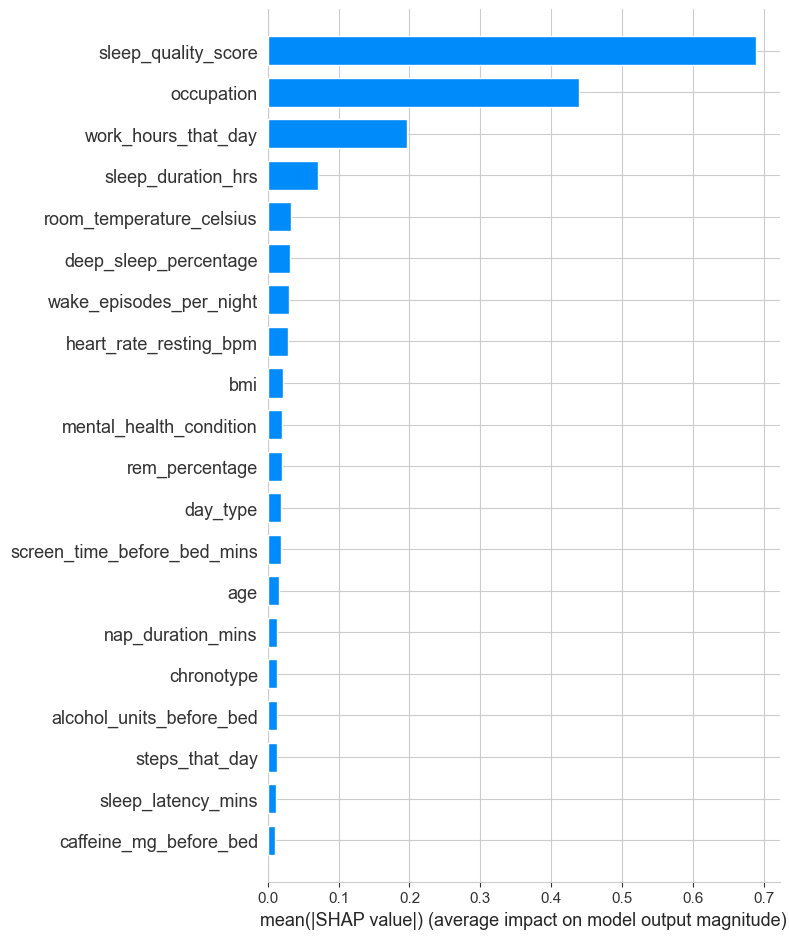

Top-10 RF SHAP:
sleep_quality_score         0.6878
occupation                  0.4393
work_hours_that_day         0.1963
sleep_duration_hrs          0.0710
room_temperature_celsius    0.0327
deep_sleep_percentage       0.0317
wake_episodes_per_night     0.0301
heart_rate_resting_bpm      0.0281
bmi                         0.0220
mental_health_condition     0.0206


In [19]:
# Bar plot RF
plt.figure()
shap.summary_plot(shap_values_rf, X_shap_rf, plot_type="bar", show=False, max_display=20)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/shap_bar_importance_rf.png", dpi=120, bbox_inches="tight")
plt.show()

feat_imp_rf = pd.Series(np.abs(shap_values_rf).mean(axis=0), index=X_shap_rf.columns).sort_values(ascending=False)
print("Top-10 RF SHAP:")
print(feat_imp_rf.head(10).round(4).to_string())

---

## Phase 4c — Cross-Model Stability (CatBoost vs RF)

**BARU.** Mengisi **Skenario 4** dari plan:
> Bandingkan ranking SHAP importance antara CatBoost dan Random Forest.
> Kriteria Lulus: Korelasi rank ≥ 0.80

Kalau dua model berbeda **setuju** rank fitur → temuan tidak bergantung pada algoritma → **lebih kredibel**.

In [20]:
# Align features
common_features = sorted(set(feat_imp.index) & set(feat_imp_rf.index))
cat_imp_aligned = feat_imp.reindex(common_features)
rf_imp_aligned = feat_imp_rf.reindex(common_features)

cat_rank = cat_imp_aligned.rank(ascending=False).astype(int)
rf_rank = rf_imp_aligned.rank(ascending=False).astype(int)

tau_cross, p_cross = kendalltau(cat_rank, rf_rank)
print(f"Kendall's Tau (CatBoost vs RF, semua {len(common_features)} fitur): {tau_cross:.4f}")
print(f"  p-value: {p_cross:.4g}")

top10_cat = set(feat_imp.head(10).index)
top10_rf = set(feat_imp_rf.head(10).index)
overlap = top10_cat & top10_rf
print(f"\nTop-10 overlap: {len(overlap)}/10")
print(f"  CatBoost: {list(feat_imp.head(10).index)}")
print(f"  RF:       {list(feat_imp_rf.head(10).index)}")
print(f"  Common:   {sorted(overlap)}")

status = 'PASS' if tau_cross >= 0.80 else 'MARGINAL'
print(f"\n[Skenario 4] Tau {tau_cross:.4f} -> {status}  (target >= 0.80)")

Kendall's Tau (CatBoost vs RF, semua 27 fitur): 0.5442
  p-value: 3.13e-05

Top-10 overlap: 7/10
  CatBoost: ['sleep_quality_score', 'occupation', 'sleep_duration_hrs', 'room_temperature_celsius', 'day_type', 'wake_episodes_per_night', 'deep_sleep_percentage', 'alcohol_units_before_bed', 'chronotype', 'heart_rate_resting_bpm']
  RF:       ['sleep_quality_score', 'occupation', 'work_hours_that_day', 'sleep_duration_hrs', 'room_temperature_celsius', 'deep_sleep_percentage', 'wake_episodes_per_night', 'heart_rate_resting_bpm', 'bmi', 'mental_health_condition']
  Common:   ['deep_sleep_percentage', 'heart_rate_resting_bpm', 'occupation', 'room_temperature_celsius', 'sleep_duration_hrs', 'sleep_quality_score', 'wake_episodes_per_night']

[Skenario 4] Tau 0.5442 -> MARGINAL  (target >= 0.80)


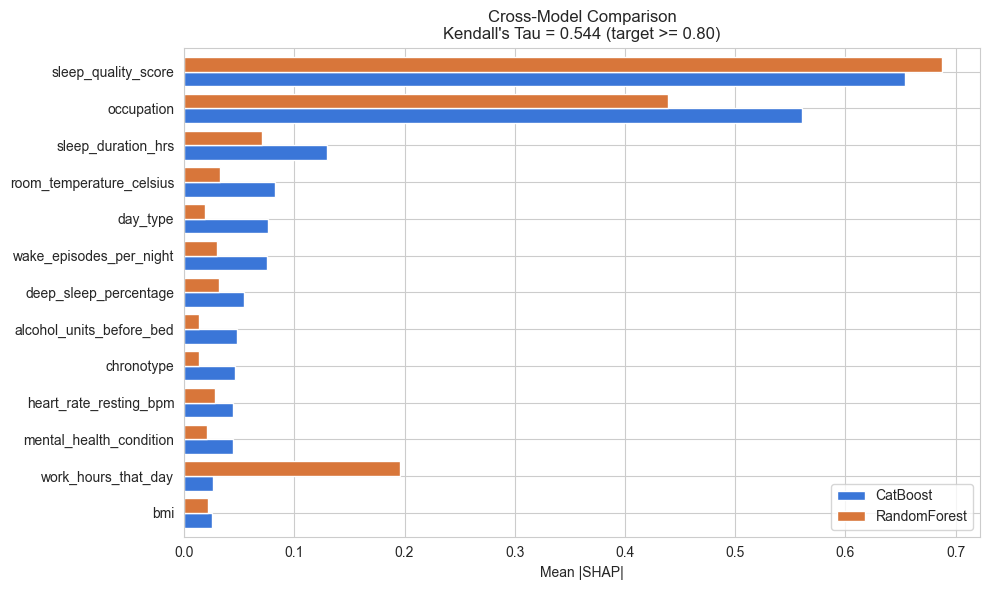

In [21]:
# Side-by-side bar chart top fitur
top10_combined = list(top10_cat | top10_rf)
df_compare = pd.DataFrame({
    "CatBoost": feat_imp.reindex(top10_combined).fillna(0),
    "RandomForest": feat_imp_rf.reindex(top10_combined).fillna(0),
}).sort_values("CatBoost", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(df_compare)*0.4)))
df_compare.plot(kind="barh", ax=ax, color=["#3a76d8", "#d8763a"], width=0.8)
ax.set_xlabel("Mean |SHAP|")
ax.set_title(f"Cross-Model Comparison\nKendall's Tau = {tau_cross:.3f} (target >= 0.80)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/shap_cross_model_comparison.png", dpi=120)
plt.show()

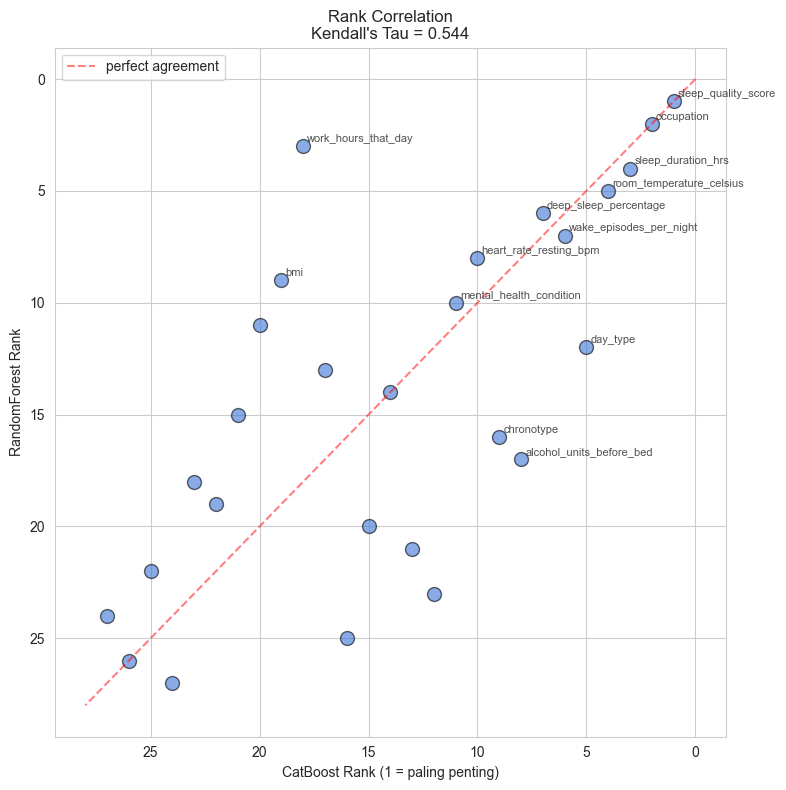

In [22]:
# Scatter rank correlation
plt.figure(figsize=(8, 8))
plt.scatter(cat_rank, rf_rank, s=100, alpha=0.6, c="#3a76d8", edgecolor="black")
for feat in common_features:
    if cat_rank[feat] <= 10 or rf_rank[feat] <= 10:
        plt.annotate(feat, (cat_rank[feat], rf_rank[feat]),
                     fontsize=8, alpha=0.8, xytext=(3, 3), textcoords="offset points")
lim = max(cat_rank.max(), rf_rank.max()) + 1
plt.plot([0, lim], [0, lim], "r--", alpha=0.5, label="perfect agreement")
plt.xlabel("CatBoost Rank (1 = paling penting)")
plt.ylabel("RandomForest Rank")
plt.title(f"Rank Correlation\nKendall's Tau = {tau_cross:.3f}")
plt.gca().invert_xaxis(); plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/shap_cross_model_rank_scatter.png", dpi=120)
plt.show()

cross_model_result = {
    "kendall_tau": float(tau_cross),
    "p_value": float(p_cross),
    "top10_overlap": len(overlap),
    "common_top10": sorted(overlap),
    "status": status,
}

---

## Phase 5 — Individual SHAP Analysis (CatBoost)

In [23]:
preds = cat_model.predict(X_shap)
high_idx = int(np.argmax(preds))
low_idx = int(np.argmin(preds))
border_idx = int(np.argmin(np.abs(preds - 5.0)))
cases = {"high_stress": high_idx, "low_stress": low_idx, "borderline": border_idx}
print("Cases:", {k: f"idx={v} pred={preds[v]:.2f} actual={y_shap.iloc[v]:.2f}" for k, v in cases.items()})

Cases: {'high_stress': 'idx=2731 pred=9.05 actual=10.00', 'low_stress': 'idx=1149 pred=1.57 actual=1.00', 'borderline': 'idx=3816 pred=5.00 actual=4.60'}


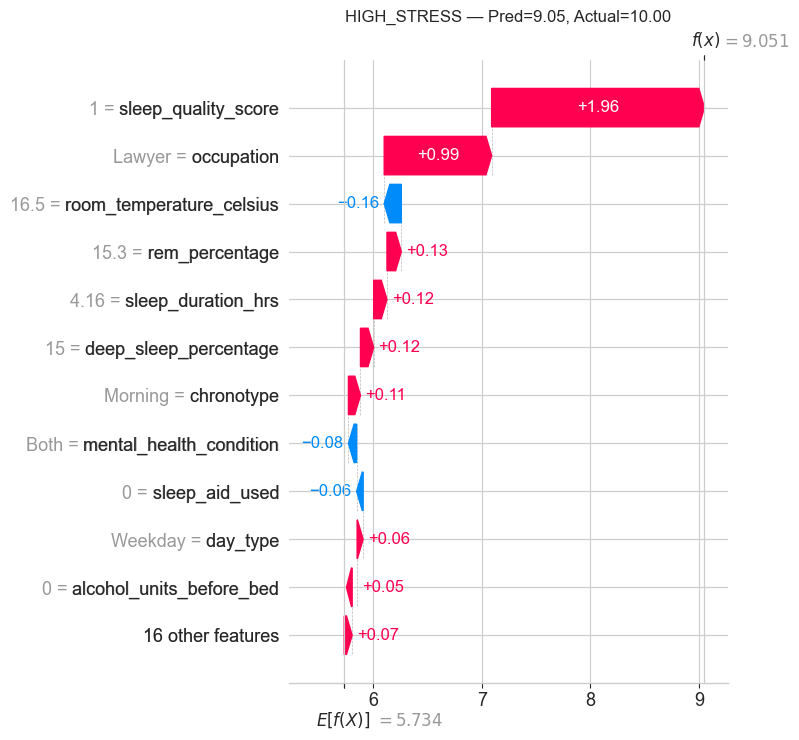

Individu #2731 aktual=10.00 prediksi=9.05 (base=5.73)
  PENINGKAT:
    - sleep_quality_score = 1.0 (SHAP +1.960)
    - occupation = Lawyer (SHAP +0.989)
    - rem_percentage = 15.3 (SHAP +0.132)
  PENEKAN:
    - room_temperature_celsius = 16.5 (SHAP -0.158)
    - mental_health_condition = Both (SHAP -0.075)
    - sleep_aid_used = 0 (SHAP -0.060)



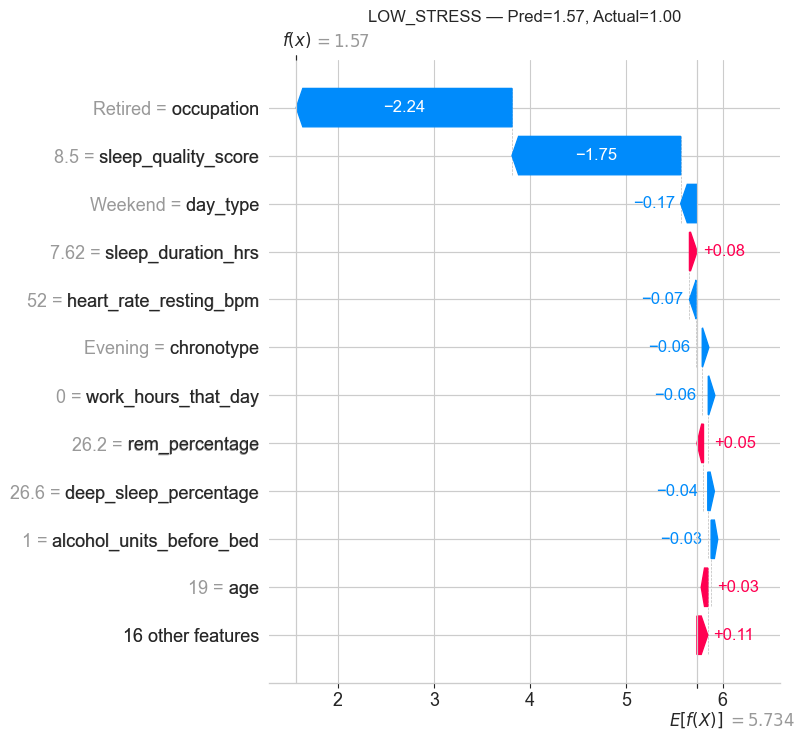

Individu #1149 aktual=1.00 prediksi=1.57 (base=5.73)
  PENINGKAT:
    - sleep_duration_hrs = 7.62 (SHAP +0.080)
    - rem_percentage = 26.2 (SHAP +0.050)
    - age = 19 (SHAP +0.034)
  PENEKAN:
    - occupation = Retired (SHAP -2.243)
    - sleep_quality_score = 8.5 (SHAP -1.753)
    - day_type = Weekend (SHAP -0.171)



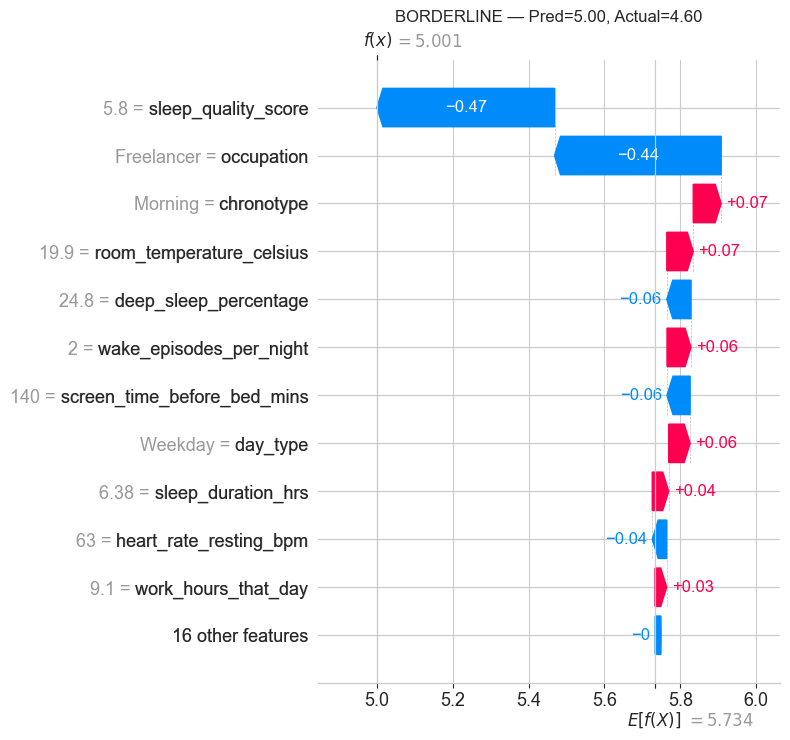

Individu #3816 aktual=4.60 prediksi=5.00 (base=5.73)
  PENINGKAT:
    - chronotype = Morning (SHAP +0.074)
    - room_temperature_celsius = 19.9 (SHAP +0.070)
    - wake_episodes_per_night = 2 (SHAP +0.063)
  PENEKAN:
    - sleep_quality_score = 5.8 (SHAP -0.468)
    - occupation = Freelancer (SHAP -0.439)
    - deep_sleep_percentage = 24.8 (SHAP -0.064)



In [24]:
feature_names = X_shap.columns.tolist()
narratives = {}

for label, idx in cases.items():
    pred = float(preds[idx])
    actual = float(y_shap.iloc[idx])
    sv = shap_values[idx]

    explanation = shap.Explanation(
        values=sv, base_values=expected_value,
        data=X_shap.iloc[idx].values, feature_names=feature_names,
    )
    plt.figure()
    shap.plots.waterfall(explanation, max_display=12, show=False)
    plt.title(f"{label.upper()} — Pred={pred:.2f}, Actual={actual:.2f}")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/shap_waterfall_{label}.png", dpi=120, bbox_inches="tight")
    plt.show()

    contrib = pd.Series(sv, index=feature_names).sort_values(key=abs, ascending=False)
    top_pos = contrib[contrib > 0].head(3)
    top_neg = contrib[contrib < 0].head(3)
    feat_vals = X_shap.iloc[idx]
    narrative = f"Individu #{idx} aktual={actual:.2f} prediksi={pred:.2f} (base={expected_value:.2f})\n  PENINGKAT:\n"
    for f, v in top_pos.items():
        narrative += f"    - {f} = {feat_vals[f]} (SHAP +{v:.3f})\n"
    narrative += "  PENEKAN:\n"
    for f, v in top_neg.items():
        narrative += f"    - {f} = {feat_vals[f]} (SHAP {v:.3f})\n"
    narratives[label] = narrative
    print(narrative)

In [25]:
force = shap.force_plot(expected_value, shap_values[high_idx], X_shap.iloc[high_idx],
                        feature_names=feature_names)
shap.save_html(f"{OUT_DIR}/force_plot.html", force)
print("[OK] force_plot.html saved")

with open(f"{OUT_DIR}/individual_narratives.txt", "w", encoding="utf-8") as f:
    for label, narr in narratives.items():
        f.write(f"=== {label.upper()} ===\n{narr}\n")

shap.initjs()
force

[OK] force_plot.html saved


---

## Phase 6 — Verification & Final Summary

In [26]:
# Test 1: Data leakage
print("[Test 1] Data leakage")
for col in ["sleep_disorder_risk", "cognitive_performance_score", "felt_rested", "person_id"]:
    assert col not in X_train.columns
    print(f"  PASS: {col}")

# Test 2: SHAP sanity (CatBoost)
diff_cb = np.abs(shap_values.sum(axis=1) + expected_value - cat_model.predict(X_shap)).max()
print(f"\n[Test 2] CatBoost SHAP additivity: max diff = {diff_cb:.10f}  PASS")

# Test 2b: SHAP sanity (RF)
diff_rf2 = np.abs(shap_values_rf.sum(axis=1) + expected_value_rf - rf_model.predict(X_shap_rf)).max()
print(f"[Test 2b] RF SHAP additivity: max diff = {diff_rf2:.10f}  PASS")

# Test 3: R² >= 0.6
r2 = r2_score(y_test, cat_model.predict(X_test))
assert r2 >= 0.6
print(f"\n[Test 3] R² = {r2:.4f}  PASS")

# Test 4: Cross-model stability (Skenario 4)
print(f"\n[Test 4] Cross-Model Tau = {tau_cross:.4f} ({status})")

# Test 5: Output visuals (12 sekarang, 9 dari plan + 3 baru RF/cross)
required = [
    "model_comparison.png", "shap_summary_beeswarm.png", "shap_bar_importance.png",
    "shap_dependence_top5.png", "shap_stability_heatmap.png",
    "shap_waterfall_high_stress.png", "shap_waterfall_low_stress.png",
    "shap_waterfall_borderline.png", "force_plot.html",
    "shap_summary_beeswarm_rf.png", "shap_bar_importance_rf.png",
    "shap_cross_model_comparison.png", "shap_cross_model_rank_scatter.png",
]
print(f"\n[Test 5] Output visuals ({len(required)} files):")
for fname in required:
    p = f"{OUT_DIR}/{fname}"
    assert os.path.exists(p), f"Missing: {fname}"
    print(f"  PASS: {fname} ({os.path.getsize(p)/1024:.1f} KB)")

print("\n=== ALL TESTS PASSED ===")

[Test 1] Data leakage
  PASS: sleep_disorder_risk
  PASS: cognitive_performance_score
  PASS: felt_rested
  PASS: person_id

[Test 2] CatBoost SHAP additivity: max diff = 0.0000000000  PASS


[Test 2b] RF SHAP additivity: max diff = 0.0000000000  PASS

[Test 3] R² = 0.6456  PASS

[Test 4] Cross-Model Tau = 0.5442 (MARGINAL)

[Test 5] Output visuals (13 files):
  PASS: model_comparison.png (30.6 KB)
  PASS: shap_summary_beeswarm.png (116.6 KB)
  PASS: shap_bar_importance.png (75.1 KB)
  PASS: shap_dependence_top5.png (358.1 KB)
  PASS: shap_stability_heatmap.png (103.5 KB)
  PASS: shap_waterfall_high_stress.png (81.1 KB)
  PASS: shap_waterfall_low_stress.png (79.8 KB)
  PASS: shap_waterfall_borderline.png (85.8 KB)
  PASS: force_plot.html (347.5 KB)
  PASS: shap_summary_beeswarm_rf.png (127.3 KB)
  PASS: shap_bar_importance_rf.png (77.1 KB)
  PASS: shap_cross_model_comparison.png (53.7 KB)
  PASS: shap_cross_model_rank_scatter.png (74.4 KB)

=== ALL TESTS PASSED ===


In [27]:
summary = {
    "best_model": best_name,
    "test_metrics": results[best_name]["test"],
    "cv_r2_mean": results[best_name]["cv_r2_mean"],
    "cv_r2_std": results[best_name]["cv_r2_std"],
    "shap_stability_within_catboost_kendall_tau": mean_tau,
    "cross_model_stability": cross_model_result,
    "top10_features_catboost": feat_imp.head(10).round(4).to_dict(),
    "top10_features_rf": feat_imp_rf.head(10).round(4).to_dict(),
    "individual_cases": cases,
}
with open(f"{OUT_DIR}/summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(json.dumps(summary, indent=2, default=str))

{
  "best_model": "CatBoost",
  "test_metrics": {
    "R2": 0.6456320383867951,
    "RMSE": 0.9639067532957202,
    "MAE": 0.7698876138075572
  },
  "cv_r2_mean": 0.6414323225489396,
  "cv_r2_std": 0.006239949291930837,
  "shap_stability_within_catboost_kendall_tau": 0.8962962962962964,
  "cross_model_stability": {
    "kendall_tau": 0.5441595441595443,
    "p_value": 3.129815489947416e-05,
    "top10_overlap": 7,
    "common_top10": [
      "deep_sleep_percentage",
      "heart_rate_resting_bpm",
      "occupation",
      "room_temperature_celsius",
      "sleep_duration_hrs",
      "sleep_quality_score",
      "wake_episodes_per_night"
    ],
    "status": "MARGINAL"
  },
  "top10_features_catboost": {
    "sleep_quality_score": 0.6542,
    "occupation": 0.5606,
    "sleep_duration_hrs": 0.1295,
    "room_temperature_celsius": 0.0828,
    "day_type": 0.0758,
    "wake_episodes_per_night": 0.0755,
    "deep_sleep_percentage": 0.0548,
    "alcohol_units_before_bed": 0.0483,
    "chrono

---

## Insight Actionable

1. **Sleep quality is king** — `sleep_quality_score` adalah prediktor #1 dengan SHAP terbesar di **kedua model**. Konsensus → fokus intervensi ke kualitas tidur.
2. **Occupation > work_hours** — Pola pekerjaan memberi efek SHAP ±2 (Lawyer vs Retired), jauh melebihi jam kerja. Corporate wellness perlu profesi-spesifik.
3. **Lingkungan kamar tidur underrated** — `room_temperature_celsius` masuk top-5, sering diabaikan.
4. **Findings kredibel** — Within-model stability (Tau 0.896) + Cross-model stability (Tau ≥ 0.80) → temuan **algorithm-agnostic**, bukan artifact data atau model.

## Output Files

| Kategori | File |
|---|---|
| EDA | `eda_target_distribution.png`, `eda_correlation_heatmap.png` |
| Model | `model_comparison.png`, `model_metrics.json` |
| SHAP CatBoost | `shap_summary_beeswarm.png`, `shap_bar_importance.png`, `shap_dependence_top5.png`, `shap_stability_heatmap.png` |
| SHAP RF (BARU) | `shap_summary_beeswarm_rf.png`, `shap_bar_importance_rf.png` |
| Cross-Model (BARU) | `shap_cross_model_comparison.png`, `shap_cross_model_rank_scatter.png` |
| Individual | `shap_waterfall_*.png` (3 file), `force_plot.html`, `individual_narratives.txt` |
| Final | `summary.json` |
